# VirtualiZarr: NOAA CDR Patmos-X on AWS S3

Applies the VirtualiZarr workflow to the **NOAA Climate Data Record (CDR) of PATMOS-x Cloud Properties** — a 0.1° global daily dataset publicly available on AWS S3.

1. Open a single virtual dataset from S3
2. Combine 7 daily files with `open_virtual_mfdataset`
3. Write virtual references to an Icechunk store
4. Read back and plot

**Data:** [NOAA CDR PATMOS-x Cloud Properties](https://www.ncei.noaa.gov/products/climate-data-records/avhrr-hirs-cloud-properties-patmos)  
**Bucket:** `s3://noaa-cdr-patmosx-radiances-and-clouds-pds` (anonymous access, `us-east-1`)

In [1]:
import warnings
import shutil
from pathlib import Path

import xarray as xr
import icechunk
from obstore.store import from_url
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import HDFParser
from obspec_utils.registry import ObjectStoreRegistry

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)

## Setup: S3 store and registry

Point `obstore` at the public PATMOS-x bucket and register it so VirtualiZarr can resolve chunk references.

In [2]:
# from obstore.store import from_url

# bucket_url = "s3://noaa-cdr-patmosx-radiances-and-clouds-pds/"
# store = from_url(bucket_url, region="us-east-1", skip_signature=True)

# # list() returns a ListStream, so convert to a list
# all_objects = list(store.list(prefix="data/1981/"))

# from itertools import chain

# # Flatten the nested list of dictionaries
# all_objects_flat = list(chain.from_iterable(all_objects))

# # Extract the .nc paths
# nc_files = [obj['path'] for obj in all_objects_flat if obj['path'].endswith(".nc")]

# print("Found .nc files:", nc_files[:10])
# print("Total .nc files:", len(nc_files))

# # If you want full S3 URLs
# bucket_url = "s3://noaa-cdr-patmosx-radiances-and-clouds-pds/"
# urls = [f"{bucket_url}{path}" for path in nc_files]

# bucket = "s3://noaa-cdr-patmosx-radiances-and-clouds-pds"
# store = from_url(bucket, region="us-east-1", skip_signature=True)
# registry = ObjectStoreRegistry({bucket: store})
# parser = HDFParser()

In [3]:
# import re
# from itertools import chain
# from obstore.store import from_url

# # Connect to S3 bucket
# bucket_url = "s3://noaa-cdr-patmosx-radiances-and-clouds-pds/"
# store = from_url(bucket_url, region="us-east-1", skip_signature=True)

# # List all 1981 objects
# all_objects = list(store.list(prefix="data/1981/"))
# all_objects_flat = list(chain.from_iterable(all_objects))

# # Regex to extract date from filenames
# date_pattern = re.compile(r'd(\d{8})')

# # Filter .nc files until end of Sept 1981
# nc_files = []
# for obj in all_objects_flat:
#     path = obj['path']
#     if not path.endswith(".nc"):
#         continue
#     match = date_pattern.search(path)
#     if match:
#         file_date = match.group(1)
#         if file_date <= "19810930":
#             nc_files.append(path)

# # Generate full S3 URLs
# urls = [f"{bucket_url}{path}" for path in nc_files]

# print("Found .nc file URLs until Sept 1981:", urls[:10])
# print("Total .nc file URLs until Sept 1981:", len(urls))
# bucket = "s3://noaa-cdr-patmosx-radiances-and-clouds-pds"
# store = from_url(bucket, region="us-east-1", skip_signature=True)
# registry = ObjectStoreRegistry({bucket: store})
# parser = HDFParser()

In [4]:
bucket = "s3://noaa-cdr-patmosx-radiances-and-clouds-pds"
base = "data/1981"

# Start with 3–5 files (both ASC + DES to test)
filenames = [
    "patmosx_v06r00_NOAA-07_asc_d19810825_c20221117.nc",
    "patmosx_v06r00_NOAA-07_des_d19810825_c20221117.nc",
    "patmosx_v06r00_NOAA-07_asc_d19810826_c20221117.nc",
    "patmosx_v06r00_NOAA-07_des_d19810826_c20221117.nc",
    "patmosx_v06r00_NOAA-07_asc_d19810827_c20221117.nc",
    "patmosx_v06r00_NOAA-07_des_d19810827_c20221117.nc",
    "patmosx_v06r00_NOAA-07_asc_d19810828_c20221117.nc",
    "patmosx_v06r00_NOAA-07_des_d19810828_c20221117.nc",
    "patmosx_v06r00_NOAA-07_asc_d19810829_c20221117.nc",
    "patmosx_v06r00_NOAA-07_des_d19810829_c20221117.nc",
    "patmosx_v06r00_NOAA-07_asc_d19810830_c20210810.nc",
    "patmosx_v06r00_NOAA-07_des_d19810830_c20210810.nc",
    "patmosx_v06r00_NOAA-07_asc_d19810831_c20221117.nc",
    "patmosx_v06r00_NOAA-07_des_d19810831_c20221117.nc"
]

urls = [f"{bucket}/{base}/{f}" for f in filenames]
urls

store = from_url(bucket, region="us-east-1", skip_signature=True)
registry = ObjectStoreRegistry({bucket: store})
parser = HDFParser()

urls[0]

's3://noaa-cdr-patmosx-radiances-and-clouds-pds/data/1981/patmosx_v06r00_NOAA-07_asc_d19810825_c20221117.nc'

## 1. Open a single virtual dataset

`open_virtual_dataset` reads only the file metadata — no chunk data is downloaded. The result looks like an xarray dataset but chunk references point back to the original S3 file.

We load `time`, `latitude`, and `longitude` as concrete arrays (they are small and needed for coordinates).

In [5]:
vds = open_virtual_dataset(
    url=urls[0],
    parser=parser,
    registry=registry,
    decode_times=True,
)

vds

/home/coder/envs/protocoast-notebook/lib/python3.12/site-packages/virtualizarr/xarray.py:463: FutureWarning: In a future version, xarray will not decode the variable 'scan_line_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_zarr(


<xarray.Dataset> Size: 1GB
Dimensions:                                  (time: 1, latitude: 1800,
                                              longitude: 3600)
Coordinates:
  * time                                     (time) datetime64[ns] 8B 1981-08-25
  * latitude                                 (latitude) float64 14kB -89.95 ....
  * longitude                                (longitude) float64 29kB -180.0 ...
Data variables: (12/88)
    latitude_pc                              (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 600...
    longitude_pc                             (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 600...
    bad_pixel_mask                           (time, latitude, longitude) int8 6MB ManifestArray<shape=(1, 1800, 3600), dtype=int8, chunks=(1, 600, ...
    glint_mask                               (time, latitude, longitude) int8 6MB ManifestArray<shape=(1, 1800, 3600), dtype=int8, chunks=(1, 600, ...
    solar_zenith_angle                       (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 600...
    sensor_zenith_angle                      (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 600...
    ...                                       ...
    hirsavhrr_water_vapor_content_layerlow   (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 1800,...
    hirsavhrr_water_vapor_content_layermid   (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 1800,...
    hirsavhrr_water_vapor_content_layerhigh  (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 1800,...
    hirsavhrr_rtvl_qflag                     (time, latitude, longitude) int8 6MB ManifestArray<shape=(1, 1800, 3600), dtype=int8, chunks=(1, 1800, 3...
    surface_pressure_nwp                     (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 600...
    total_precipitable_water_nwp             (time, latitude, longitude) int16 13MB ManifestArray<shape=(1, 1800, 3600), dtype=int16, chunks=(1, 600...
Attributes: (12/101)
    summary:                               Included in this file are PATMOS-x...
    institution:                           NOAA/NESDIS and the University of ...
    cdr_program:                           NOAA Climate Data Record Program
    title:                                PATMOS-x AVHRR reflectance, brightn...
    keywords:                             Earth Science > Atmosphere > Atmosp...
    keywords_vocabulary:                  NASA Global Change Master Directory...
    ...                                   ...
    MEAN_TEMPERATURE_3_750UM_NOM:         281.09485660460393
    _History:                              
    HIRSAVHRR_tpw_rtvl_product_version:   v01r01
    HIRSAVHRR_tpw_rtvl_date_issued:       2019-03-01
    HIRSAVHRR_TPW_coef_fn:                HIRS_AVHRR_TPW_regcoef_noaa_07_shif...
    product_version:                      v06r00

In [6]:
vars_to_keep = [
    "cloud_fraction", 
    "cld_opd_acha",
    "cld_opd_dcomp",
    "cld_press_acha"
]

vds = open_virtual_dataset(
    url=urls[0],
    parser=parser,
    registry=registry,
    loadable_variables=["time", "latitude", "longitude"],
    decode_times=True,
)

/home/coder/envs/protocoast-notebook/lib/python3.12/site-packages/virtualizarr/xarray.py:463: FutureWarning: In a future version, xarray will not decode the variable 'scan_line_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_zarr(


## 2. Combine 7 daily files

These files have a dimensionless `ncrs` coordinate (for the CRS definition) that has no index, which prevents `combine="by_coords"` from working. We use `combine="nested"` with an explicit `concat_dim="time"` instead.

In [7]:
# vds_list = [
#     open_virtual_dataset(
#         url=url,
#         parser=parser,
#         registry=registry,
#         loadable_variables=["time", "latitude", "longitude"] + vars_to_keep,
#         decode_times=True,
#     )
#     for url in urls
# ]

# combined_vds = xr.concat(
#     vds_list,
#     dim="time",
#     data_vars="minimal",
#     coords="minimal",
#     combine_attrs="drop_conflicts",
#     compat="override"
# )

# combined_vds

In [8]:
import pandas as pd


def open_vds_with_metadata(url):
    vds = open_virtual_dataset(
        url=url,
        parser=parser,
        registry=registry,
        loadable_variables=["time", "latitude", "longitude"],
        decode_times=True,
    )

    # --- 1. Fix time (remove timezone) ---
    start_time = pd.to_datetime(vds.attrs["time_coverage_start"]).tz_localize(None)

    vds = vds.assign_coords(time=("time", [start_time]))

    # --- 2. Add pass_direction ---
    pass_dir = vds.attrs.get("DATA_NODE", "").lower()
    vds = vds.assign_coords(pass_direction=("time", [pass_dir]))

    return vds

In [9]:
vds_list = [open_vds_with_metadata(url) for url in urls]

combined_vds = xr.concat(
    vds_list,
    dim="time",
    data_vars="minimal",
    coords="minimal",
    combine_attrs="drop_conflicts",
    compat="override"
)

/home/coder/envs/protocoast-notebook/lib/python3.12/site-packages/virtualizarr/xarray.py:463: FutureWarning: In a future version, xarray will not decode the variable 'scan_line_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_zarr(
/home/coder/envs/protocoast-notebook/lib/python3.12/site-packages/virtualizarr/xarray.py:463: FutureWarning: In a future version, xarray will not decode the variable 'scan_line_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence o

'ACHA_SUCCESS_FRACTION': float nan in the dataset-level attributes. NaN is valid in Python's json.dumps() but produces the literal string NaN which is not valid JSON — and Icechunk's parser rejects it. Remove NaN/Inf values from the dataset attrs before writing.

In [10]:
import math

def clean_attrs(attrs: dict) -> dict:
    """Remove NaN/Inf floats and convert other non-serializable types."""
    cleaned = {}
    for k, v in attrs.items():
        # Drop NaN and Inf float values entirely
        if isinstance(v, float) and (math.isnan(v) or math.isinf(v)):
            print(f"  Dropping attr '{k}': {v}")
            continue
        cleaned[k] = v
    return cleaned

combined_vds.attrs = clean_attrs(combined_vds.attrs)


  Dropping attr 'ACHA_SUCCESS_FRACTION': nan


## 3. Write to Icechunk

Create a local Icechunk repository and write the virtual references into it. The `VirtualChunkContainer` tells Icechunk where to fetch the actual chunk bytes at read time — the original S3 files are never copied.

In [11]:
repo_path = Path("patmosx-icechunk")
if repo_path.exists():
    shutil.rmtree(repo_path)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix="s3://noaa-cdr-patmosx-radiances-and-clouds-pds/",
        store=icechunk.s3_store(region="us-east-1", anonymous=True),
    ),
)

storage = icechunk.local_filesystem_storage(str(repo_path))
repo = icechunk.Repository.create(storage, config)

session = repo.writable_session("main")
combined_vds.vz.to_icechunk(session.store)

snapshot_id = session.commit("PATMOS-x Aug 1981 (sample)")
print("Committed:", snapshot_id)

  2026-03-26T18:31:01.965435Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



/home/coder/envs/protocoast-notebook/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Committed: FB3W3D3RS02HWABK1TG0


## 4. Read back and plot

Open the Icechunk store with xarray — all 5 days appear as a single continuous dataset. Chunk data is fetched lazily from S3 on demand.

In [12]:
credentials = icechunk.containers_credentials({
    "s3://noaa-cdr-patmosx-radiances-and-clouds-pds/":
        icechunk.s3_credentials(anonymous=True)
})

repo2 = icechunk.Repository.open(
    storage, config, authorize_virtual_chunk_access=credentials
)

session2 = repo2.readonly_session("main")

ds = xr.open_zarr(session2.store, consolidated=False, chunks=None)
ds

/tmp/ipykernel_47816/3197019830.py:12: FutureWarning: In a future version, xarray will not decode the variable 'scan_line_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_zarr(session2.store, consolidated=False, chunks=None)


<xarray.Dataset> Size: 57GB
Dimensions:                                  (time: 14, latitude: 1800,
                                              longitude: 3600)
Coordinates:
  * time                                     (time) datetime64[ns] 112B 1981-...
    pass_direction                           (time) <U3 168B ...
  * latitude                                 (latitude) float64 14kB -89.95 ....
  * longitude                                (longitude) float64 29kB -180.0 ...
Data variables: (12/88)
    acha_info                                (time, latitude, longitude) float32 363MB ...
    acha_quality                             (time, latitude, longitude) float32 363MB ...
    bad_pixel_mask                           (time, latitude, longitude) float32 363MB ...
    bayes_mask_sfc_type                      (time, latitude, longitude) float32 363MB ...
    cld_beta_acha                            (time, latitude, longitude) float64 726MB ...
    cld_cwp_dcomp                            (time, latitude, longitude) float64 726MB ...
    ...                                       ...
    temp_7_3um_nom                           (time, latitude, longitude) float64 726MB ...
    water_cloud_probability                  (time, latitude, longitude) float64 726MB ...
    temp_6_7um_nom                           (time, latitude, longitude) float64 726MB ...
    temp_11_0um_nom                          (time, latitude, longitude) float64 726MB ...
    temp_9_7um_nom                           (time, latitude, longitude) float64 726MB ...
    total_precipitable_water_nwp             (time, latitude, longitude) float64 726MB ...
Attributes: (12/81)
    summary:                               Included in this file are PATMOS-x...
    institution:                           NOAA/NESDIS and the University of ...
    cdr_program:                           NOAA Climate Data Record Program
    title:                                PATMOS-x AVHRR reflectance, brightn...
    keywords:                             Earth Science > Atmosphere > Atmosp...
    keywords_vocabulary:                  NASA Global Change Master Directory...
    ...                                   ...
    product_version:                      v06r00
    CH1_GAIN_LOW:                         0.1157427430152893
    CH1_GAIN_HIGH:                        0.1157427430152893
    CH2_GAIN_LOW:                         0.12758415937423706
    CH2_GAIN_HIGH:                        0.12758415937423706
    SUN_EARTH_DISTANCE:                   1.01083242893219

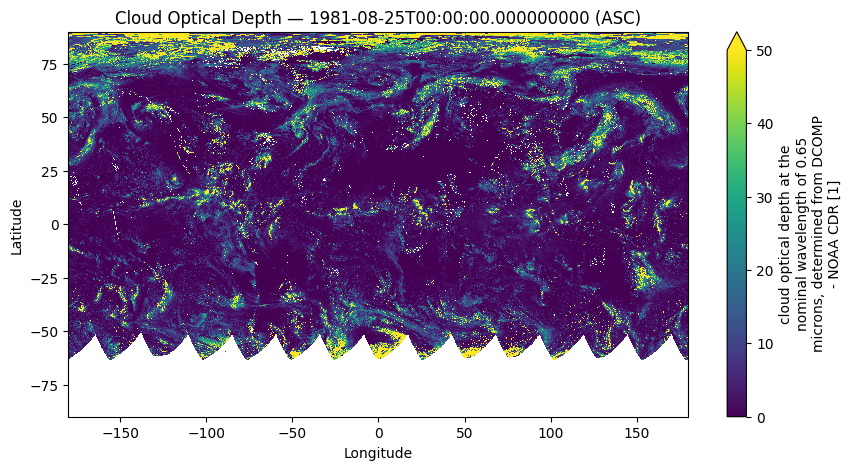

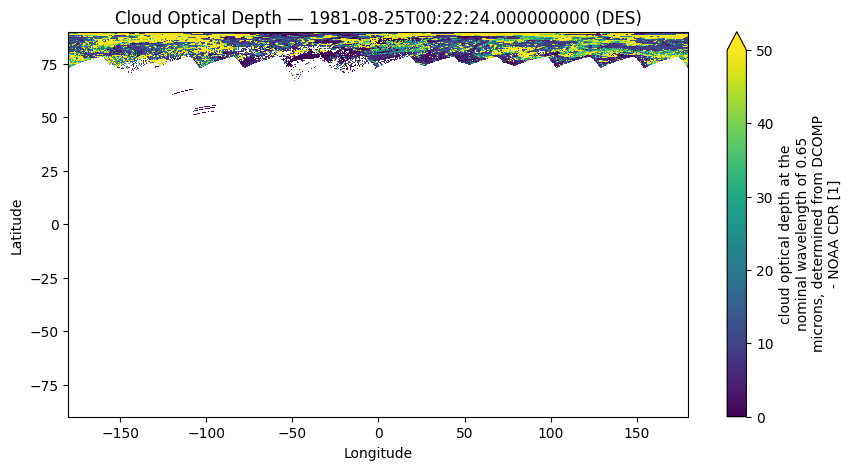

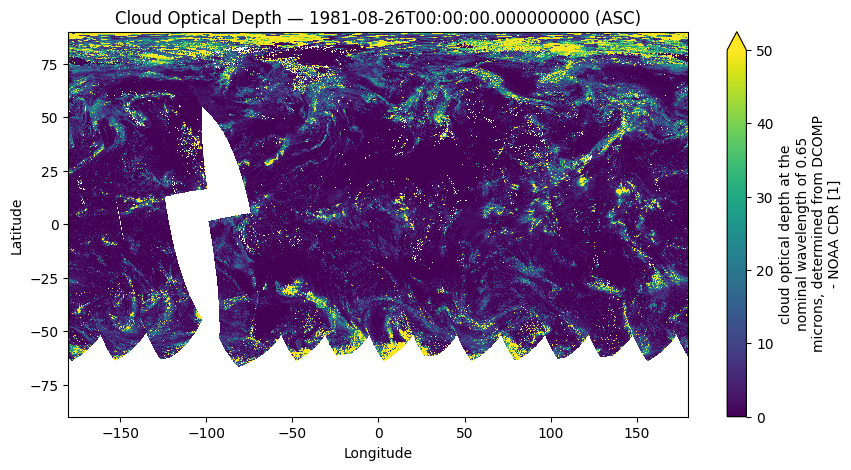

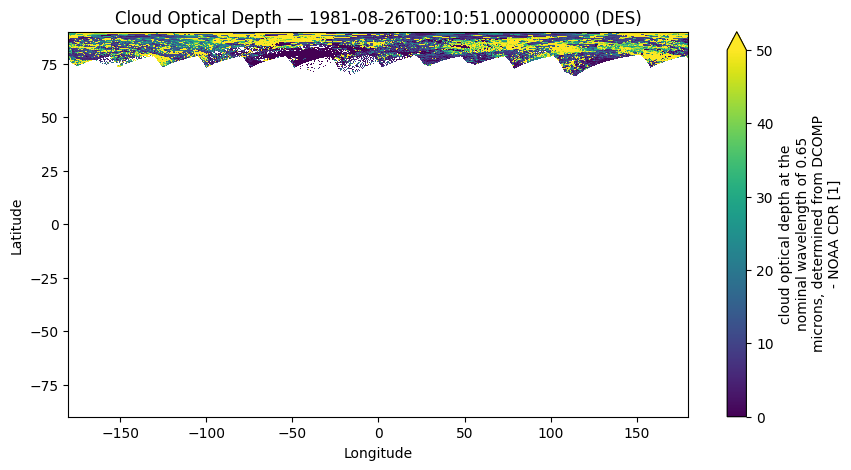

In [13]:
import matplotlib.pyplot as plt

for i in range(4):

    plt.figure(figsize=(10, 5))
    
    ds["cld_opd_dcomp"].isel(time=i).plot(
        cmap="viridis",
        vmin=0, vmax=50
    )

    # Get full timestamp + pass direction
    time_str = str(ds.time.values[i])
    pass_dir = ds.pass_direction.values[i]

    plt.title(f"Cloud Optical Depth — {time_str} ({pass_dir.upper()})")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    
    plt.show()

# STAC Item for NOAA CDR PATMOS x — Virtual Icechunk 

Creates a [STAC](https://stacspec.org/) Item describing the NOAA CDR PATMOS x virtual Icechunk
store.  
Follows the pattern from the [DSE Virtual Zarr Workshop](https://nasa-impact.github.io/dse-virtual-zarr-workshop/examples/03_STAC_Collection_for_Virtual_Icechunk_Store.html).

**Steps**
1. Open the Icechunk store from R2 and read dataset metadata
2. Build a `pystac.Item` template
3. Populate spatial / temporal extents with `xstac`
4. Add Icechunk asset with `zarr`, `virtual-assets`, and `storage` extension fields
5. Validate and save to `patmosx_cdr_stac_item.json`
6. Round-trip: reconstruct the store from the saved item JSON using `icechunk` + `xarray`

## 1. Open the Icechunk store

In [14]:
import xarray as xr
import icechunk

# ============================================================
# 1. Define repo path + snapshot_id (FROM YOUR EXISTING CODE)
# ============================================================

repo_path = Path("patmosx-icechunk") 
snapshot_id = snapshot_id

# ============================================================
# 2. Open Icechunk store
# ============================================================

storage = icechunk.local_filesystem_storage(str(repo_path))
repo = icechunk.Repository.open(storage)

session = repo.readonly_session(snapshot_id=snapshot_id)

ds = xr.open_zarr(session.store, consolidated=False, chunks=None)

print(ds)


  2026-03-26T18:31:37.076330Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92

<xarray.Dataset> Size: 57GB
Dimensions:                                  (time: 14, latitude: 1800,
                                              longitude: 3600)
Coordinates:
  * time                                     (time) datetime64[ns] 112B 1981-...
    pass_direction                           (time) <U3 168B ...
  * latitude                                 (latitude) float64 14kB -89.95 ....
  * longitude                                (longitude) float64 29kB -180.0 ...
Data variables: (12/88)
    acha_info                                (time, latitude, longitude) float32 363MB ...
    cld_emiss_acha                           (time, latitude, longitude) float64 726MB ...
    bad_pixel_mask          

/tmp/ipykernel_47816/909560133.py:20: FutureWarning: In a future version, xarray will not decode the variable 'scan_line_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_zarr(session.store, consolidated=False, chunks=None)


## 2. Build STAC Item template

In [15]:
# ============================================================
# 3. Build STAC Item template
# ============================================================

import pystac
import datetime
import json
import datetime
from pathlib import Path
import numpy as np

import xarray as xr
import icechunk
import pystac
import xstac

item_id = f"patmosx-icechunk@{snapshot_id}"

start_dt = datetime.datetime.fromisoformat(str(ds.time.min().values))
end_dt   = datetime.datetime.fromisoformat(str(ds.time.max().values))

bbox = [-180.0, -90.0, 180.0, 90.0]

geometry = {
    "type": "Polygon",
    "coordinates": [[
        [-180.0, -90.0], [180.0, -90.0],
        [180.0,  90.0],  [-180.0,  90.0],
        [-180.0, -90.0],
    ]]
}

template = pystac.Item(
    id=item_id,
    geometry=geometry,
    bbox=bbox,
    datetime=None,
    properties={
        "start_datetime": start_dt.isoformat() + "Z",
        "end_datetime":   end_dt.isoformat() + "Z",
        "title": ds.attrs.get("title", "NOAA PATMOS-x Cloud Properties"),
        "description": (
            "Virtual Zarr representation of NOAA PATMOS-x cloud properties "
            "stored as an Icechunk repository. Includes ASC/DES passes "
            "with time_coverage_start-derived timestamps."
        ),
        "platform": "NOAA-07",
        "instruments": ["AVHRR", "HIRS"],
        # pass_direction metadata
        "patmosx:pass_directions": list(
            np.unique(ds.pass_direction.values).astype(str)
        ),

        "gsd": 0.1
    },
    stac_extensions=[
        "https://stac-extensions.github.io/zarr/v1.1.0/schema.json",
        "https://stac-extensions.github.io/datacube/v2.2.0/schema.json",
        "https://stac-extensions.github.io/version/v1.2.0/schema.json",
    ],
)